In [ ]:
import numpy as np
import scipy as sp 
from pprint import pprint
from matplotlib import pyplot as plt

import morph_analyses as m
 
%load_ext autoreload
%autoreload 2

%matplotlib inline

# Mouse information

Information about each mouse is stored in morph_analyses.mouse_metadata . Details of each imaging session for each mouse and for each group of mice are saved in nested dictionaries. 

- 'Rare Morph' sessions are saved in morph_analyses.mouse_metadata.rare_sessions
- 'Frequent Morph' sessions are saved in morph_analyses.mouse_metadata.frequent_sessions
- 'Frequent Morph with Decision' (Extended Data Fig 10) sessions are saved in morph_analyses.mouse_metadata.frequent_w_decision_sessions

Each mouse's metadata and each imaging session's metadata are saved in a dictionary inside each of the dictionaries listed above. Additionally, sessions are broken up by 'training sessions' (first 7 days of behavior in the VR task) or 'test sessions' (days 8-N, number of sessions variable across mice). Information about VR only sessions is not included in this repository. 

The main piece of metadata that is useful for replication is the 'day' for each imaging session. This is also referred to as the 'session number' in the manuscript

In [2]:
# grab an example mouse

mouse = 'R2'

if mouse in m.mouse_metadata.rare_mice:
    metadata = m.mouse_metadata.rare_sessions[mouse]
    fd = False
elif mouse in m.mouse_metadata.frequent_mice:
    metadata = m.mouse_metadata.frequent_sessions[mouse]
    fd = False
elif mouse in m.mouse_metadata.frequent_w_decision_mice:
    metadata = m.mouse_metadata.frequent_w_decision_sessions[mouse]
    fd = True
else:
    raise Exception(f"mouse {mouse} does not exist")


print(f'mouse: {mouse}')

mouse: R2


In [3]:
# look at mouse's metadata

pprint(metadata)

{'alias': '4139265.4',
 'date_of_birth': datetime.datetime(2018, 11, 7, 0, 0),
 'functional_indicator': 'AAV-PHP.eB-EF1a-DIO-GCaMP6f',
 'genotype': 'CaMKII-Cre',
 'imaging_lambda': 920,
 'notes': '',
 'sex': 'M',
 'test_sessions': ({'date_str': '17_02_2019',
                    'datetime': datetime.datetime(2019, 2, 17, 0, 0),
                    'day': 8,
                    'scan': 8,
                    'scene': 'TwoTower_foraging',
                    'session': 2},
                   {'date_str': '18_02_2019',
                    'datetime': datetime.datetime(2019, 2, 18, 0, 0),
                    'day': 9,
                    'scan': 3,
                    'scene': 'TwoTower_foraging',
                    'session': 2},
                   {'date_str': '19_02_2019',
                    'datetime': datetime.datetime(2019, 2, 19, 0, 0),
                    'day': 10,
                    'scan': 2,
                    'scene': 'TwoTower_foraging',
                    'session': 2},


# Loading data and tour of session class

The following cells will pick an example session, load the session direclty from the downloaded DANDI repository (see notebook 01_DOWNLOAD_DATASETS.ipynb), and walk through the contents of the file. 

In [4]:
# pick a sesison 

traintest = 'test' # look are 'training' or 'test' sessions
session_ind = 1 # listed in chronological order, so higher indices are later sessions
                # these are always consecutive days in which the mouse ran in VR
                # for test sessions (except data from Extended Data Fig 10) but not training sessions.
                # There were occasional days (usually weekends) where mice received water but did not
                # run in VR
sess_deets = metadata[f'{traintest}_sessions'][session_ind]
pprint(sess_deets)

{'date_str': '18_02_2019',
 'datetime': datetime.datetime(2019, 2, 18, 0, 0),
 'day': 9,
 'scan': 3,
 'scene': 'TwoTower_foraging',
 'session': 2}


In [5]:
# This classmethod generates a session object that is used for many of the analyses. 
# The path to the NWB file is autogenerated using morph_analyses.params.dandi_download_dir, 
# so make sure that is set. 

if traintest=='test':
    _traintest = 'testing'
else:
    _traintest = 'training'

sess = m.sess.CA1MorphSession.from_nwb(
    mouse, # mouse id 
    _traintest, # 'training' or 'testing
    sess_deets['day']
    )

In [6]:
# The session class stores metadata as attributes, but does not save store all of the NWB metadata. 
# See the NWB file for even more metatdata

# print some of the metadata
attributes = ('mouse', 'day')
for attr in attributes:
    print(f'self.{attr} = {sess.__getattribute__(attr)}')


self.mouse = R2
self.day = 9


In [7]:
sess.s2p_ops.keys()

dict_keys(['meanImg', 'Ly', 'Lx', 'Fs'])

In [45]:
# VR data is stored in a pandas array 

# columns: 
# position - position on track in cm. -500 is a default value prior to the 
#            start of the scan. Other negative values correspond to inter-trial-intervals
# morph value - shared more value around which other aspects of the scene were jittered.
#               -1 is a default value when the track is not visible to the mouse. 
#               Otherwise this should be 0, .25, .5, .75, or 1
# wall jitter - jitter added to wall pattern morph value
# background jitter - jitter added to background color morph value
# tower jitter - jitter added to tower color morph value
# licks - average lick count during single imaging frame
# reward - boolean corresponding to reward delivery times
# trial number - trial number
# trial start - boolean corresponding to when the mouse enters the track
# teleport - boolean. Trial end time when the mouse is teleported to the dark hallway
# speed - instantaneous speed 

sess.vr_data.head()

,background jitter,licks,morph value,position,reward,speed,teleport,tower jitter,trial number,trial start,wall jitter,time
0,-1.0,0.0,-1.0,-500.0,0.0,0.0,0.0,-1.0,-1.0,0.0,-1.0,0.000000
1,-1.0,0.0,-1.0,-500.0,0.0,0.0,0.0,-1.0,-1.0,0.0,-1.0,0.064679
2,-1.0,0.0,-1.0,-500.0,0.0,0.0,0.0,-1.0,-1.0,0.0,-1.0,0.129358
3,-1.0,0.0,-1.0,-500.0,0.0,0.0,0.0,-1.0,-1.0,0.0,-1.0,0.194037
4,-1.0,0.0,-1.0,-500.0,0.0,0.0,0.0,-1.0,-1.0,0.0,-1.0,0.258717


In [46]:
# Useful information about each trial is stored in a dictionary of numpy arrays
# most useful entries are the morph values for each trial and the 'effective morph'
# which is the shared morph value plus the wallJitter
# See morph_analyses.utilties.by_trial_info() for more information on each entry
sess.trial_info.keys()

dict_keys(['morphs', 'max_pos', 'rewards', 'zone0_licks', 'zone1_licks', 'zone0_speed', 'zone1_speed', 'pcnt', 'wallJitter', 'towerJitter', 'bckgndJitter', 'pos_lick', 'omissions', 'reward_pos', 'rzone_entry', 'effective_morph'])

In [47]:
# Indices for trial starts and stops are stored as separate attributes for convenience
for start, stop in zip(sess.trial_start_inds, sess.teleport_inds):
    print(start, stop)

149 383
417 644
676 868
899 1121
1148 1325
1352 1541
1565 1805
1975 2165
2190 2361
2384 2591
2615 2824
2992 3170
3194 3382
3406 3580
3605 3769
3792 3991
4157 4324
4347 4513
4537 4758
4784 4955
4985 5148
5177 5324
5348 5518
5543 5682
5706 5912
5938 6129
6153 6373
6540 6751
6775 7007
7039 7238
7404 7588
7614 7782
7807 8012
8037 8228
8253 8436
8459 8683
8708 8896
8921 9107
9131 9334
9359 9569
9787 9976
10000 10173
10196 10390
10419 10597
10621 10835
10861 11046
11070 11242
11267 11433
11456 11645
11672 11877
11901 12050
12075 12236
12260 12465
12491 12661
12688 12862
12886 13118
13286 13486
13510 13734
13757 13973
14140 14333
14502 14735
14762 14942
14965 15160
15188 15363
15388 15583
15607 15772
15796 15985
16011 16203
16227 16402
16425 16609
16635 16806
16831 17033
17058 17212
17236 17453
17483 17674
17698 17855
17879 18065
18089 18286
18309 18502
18528 18697
18721 18949
18974 19165
19190 19391
19415 19636
19661 19864
19889 20098
20264 20477
20645 20799
20824 21040
21207 21394
21418 216

In [48]:
# Cell timeseries are stored in a dictionary of numpy arrays.
# Arrays are either N cells x N timepoints. 
# Behavior data can also be stored in the dictionary as 1 x N timepoints arrays. 
# For safe adding/removing use sess.add_timeseries(tsname=arr)/sess.rm_timeseries('tsname')

# Timeseries:
# F - raw fluorescence
# Fneu - neuropil fluorescence
# dff - delta F / F from neuropil corrected fluorescence
# spks - deconvolved activity rate
# spks_norm - each cell's spks timeseries is divided by its 99th percentile

print('Data in default session class')
print(sess.timeseries.keys())

print("\n\ndata shape")
print(sess.timeseries['spks'].shape)

# add fake data
fake_data_arr = np.ones_like(sess.timeseries['F'])
sess.add_timeseries(fake_data=fake_data_arr)
print(f"\n\nfake data shape {sess.timeseries['fake_data'].shape}")

# remove fake data
print("\n\ndict keys")
print(sess.timeseries.keys())
sess.rm_timeseries('fake_data')
print("\n\nafter removing fake data")
print(sess.timeseries.keys())
 

Data in default session class
dict_keys(['F', 'Fneu', 'dff', 'spks', 'spks_norm', 'licks', 'reward', 'speed'])


data shape
(1656, 29023)


fake data shape (1656, 29023)


dict keys
dict_keys(['F', 'Fneu', 'dff', 'spks', 'spks_norm', 'licks', 'reward', 'speed', 'fake_data'])


after removing fake data
dict_keys(['F', 'Fneu', 'dff', 'spks', 'spks_norm', 'licks', 'reward', 'speed'])


In [49]:
# Position binned trial matrices are stored similarly
#  Arrays are N trials x N positions x N cells
# Behavior data is N trials x N positions x 1
# Bin edges and bin centers are also stored
# 10 cm bins are used by default. This is 
# about as small as you can go given calcium imaging rates
# and mouse running speeds to ensure each bin is actually sampled.

# see sess.add_pos_binned_trial_matrix and 
# sess.rm_pos_binned_trial_matrix (in two_photon_utils base class)
# for safe adding and removal

# Cell indices are preserved from sess.timeseries

sess.trial_matrices.keys()

dict_keys(['F', 'Fneu', 'dff', 'spks', 'spks_norm', 'licks', 'reward', 'speed', 'bin_edges', 'bin_centers'])

In [50]:
# Precomputed place cell information is also stored.
# Place cells were calculated for each morph value separately.
# For each morph value we store an array which contains each cells 
# spatial information (SI), p value from shuffling, and a boolean mask 
# (True = p<.05, False = p>.05)

# For example the spatial information for all of the cells from morph 0
# sess.place_cell_info['SI'][0]
# or morph 1
# sess.place_cell_info['SI'][1]

pprint(sess.place_cell_info)

# place cells can be recomputed using sess.place_cells_calc

{'SI': {0.0: array([0.53341352, 0.00523014, 2.66661857, ..., 0.09966162, 0.05661933,
       0.20970337], shape=(1656,)),
        0.25: array([0.62298272, 0.25392765, 2.01708648, ..., 0.11806236, 0.13191103,
       0.12158523], shape=(1656,)),
        0.5: array([0.77922196, 0.42365171, 1.61673236, ..., 0.10911101, 0.22127   ,
       0.09714362], shape=(1656,)),
        0.75: array([1.12814998, 0.27336938, 2.28735531, ..., 0.46664953, 0.12705096,
       0.37534226], shape=(1656,)),
        1.0: array([0.93596594, 0.4235571 , 1.05986358, ..., 0.26904339, 0.00758023,
       0.09221875], shape=(1656,))},
 'masks': {0.0: array([False, False,  True, ..., False, False, False], shape=(1656,)),
           0.25: array([False, False,  True, ..., False, False, False], shape=(1656,)),
           0.5: array([False, False,  True, ..., False, False, False], shape=(1656,)),
           0.75: array([False, False,  True, ..., False, False, False], shape=(1656,)),
           1.0: array([False,  True,  True

In [51]:
# a subset of suite2p ops information is stored
pprint(sess.s2p_ops)

{'Fs': np.float64(15.4609),
 'Lx': 796,
 'Ly': 512,
 'meanImg': array([[202.96041071, 337.95389863, 411.45129725, ..., 368.60527857,
        332.28566999, 163.14605658],
       [411.7380009 , 646.84984323, 756.32426007, ..., 746.97040278,
        687.08427799, 365.94890259],
       [413.86490025, 647.42245805, 753.12248906, ..., 743.70974744,
        689.41842676, 362.85973194],
       ...,
       [399.75464287, 630.14026806, 740.5448782 , ..., 719.65778865,
        606.34834442, 375.3492058 ],
       [322.95255487, 555.43393171, 664.82706819, ..., 700.33228819,
        583.69572408, 360.61003342],
       [129.07938532, 299.65823657, 402.28236226, ..., 343.8122179 ,
        287.763429  , 172.94738656]], shape=(512, 796))}


In [52]:
# cell footprints are stored in sess.s2p_stats
# array of dictionaries (Ncells,) with pixels included in each cell's footprint
pprint(sess.s2p_stats)

array([{'ypix': array([258, 259, 259, 259, 259, 259, 260, 260, 260, 260, 260, 260, 260,
              261, 261, 261, 261, 261, 261, 261, 261, 261, 262, 262, 262, 262,
              262, 262, 262, 262, 262, 263, 263, 263, 263, 263, 263, 263, 263,
              263, 263, 264, 264, 264, 264, 264, 264, 264, 264, 264, 264, 264,
              264, 264, 265, 265, 265, 265, 265, 265, 265, 265, 265, 265, 265,
              265, 265, 265, 266, 266, 266, 266, 266, 266, 266, 266, 266, 266,
              266, 266, 266, 266, 266, 266, 266, 267, 267, 267, 267, 267, 267,
              267, 267, 267, 267, 267, 267, 267, 267, 267, 267, 268, 268, 268,
              268, 268, 268, 268, 268, 268, 268, 268, 269, 269, 269, 269, 270,
              270, 270, 270, 270, 271, 271], dtype=uint32), 'xpix': array([241, 238, 239, 240, 241, 242, 237, 238, 239, 240, 241, 242, 243,
              236, 237, 238, 239, 240, 241, 242, 243, 244, 235, 236, 237, 238,
              239, 240, 241, 242, 243, 234, 235, 236, 237, 23

# Example analyses used throughout paper

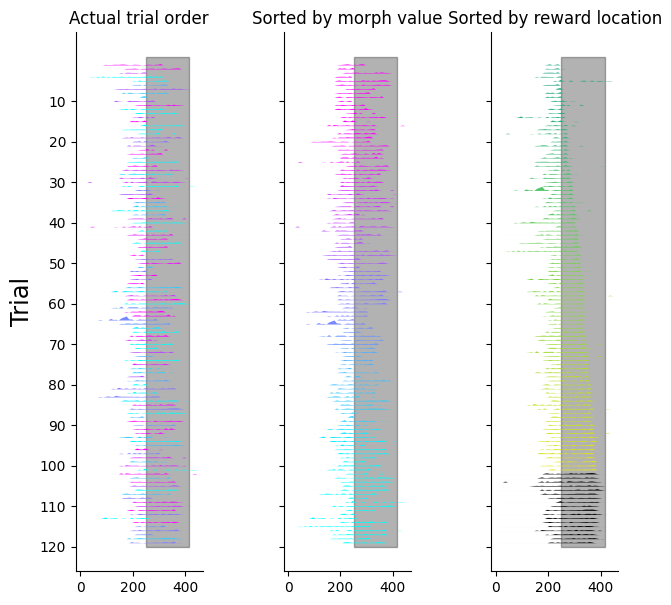

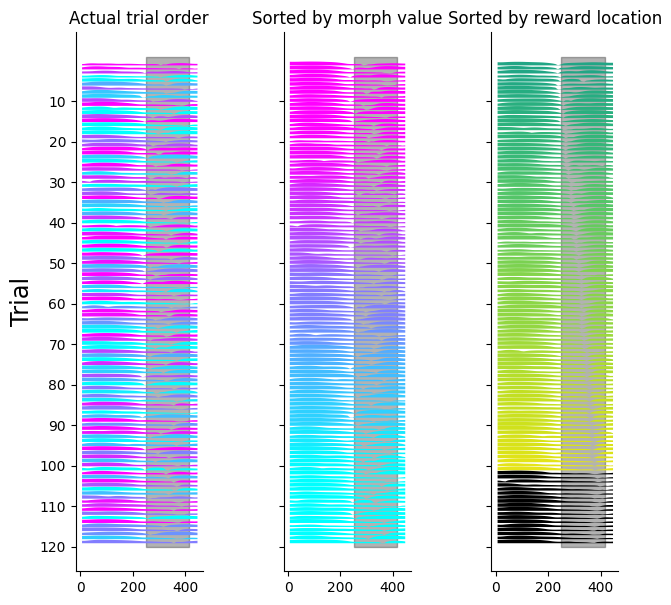

In [53]:
# licking and running behavior
effMorph = sess.trial_info['effective_morph']
reward_pos = sess.trial_info['rzone_entry']
reward_pos[np.isnan(reward_pos)]= 480


max_pos = np.copy(sess.trial_info['max_pos'])
max_pos[max_pos>440]=np.nan


lick_trial_mat = sess.trial_matrices['licks']
centers = sess.trial_matrices['bin_centers']
eff_morph = sess.trial_info['effective_morph']

if not fd:
    f_lick, axarr_lick = m.behavior.behavior_raster_foraging(lick_trial_mat/np.nanmax(lick_trial_mat.ravel()),
                                                        centers,eff_morph,reward_pos/390.,smooth=False)

    speed_trial_mat = sess.trial_matrices['speed']
    f_speed,axarr_speed = m.behavior.behavior_raster_foraging(speed_trial_mat/np.nanmax(speed_trial_mat.ravel()),
                                                        centers,eff_morph,reward_pos/390.,smooth=False) 
else:
    f_lick, axarr_lick = m.behavior.behavior_raster_task(lick_trial_mat/np.nanmax(lick_trial_mat.ravel()),
                                                        centers,eff_morph,reward_pos/390.,smooth=False)

    speed_trial_mat = sess.trial_matrices['speed']
    f_speed,axarr_speed = m.behavior.behavior_raster_task(speed_trial_mat/np.nanmax(speed_trial_mat.ravel()),
                                                        centers,eff_morph,reward_pos/390.,smooth=False) 

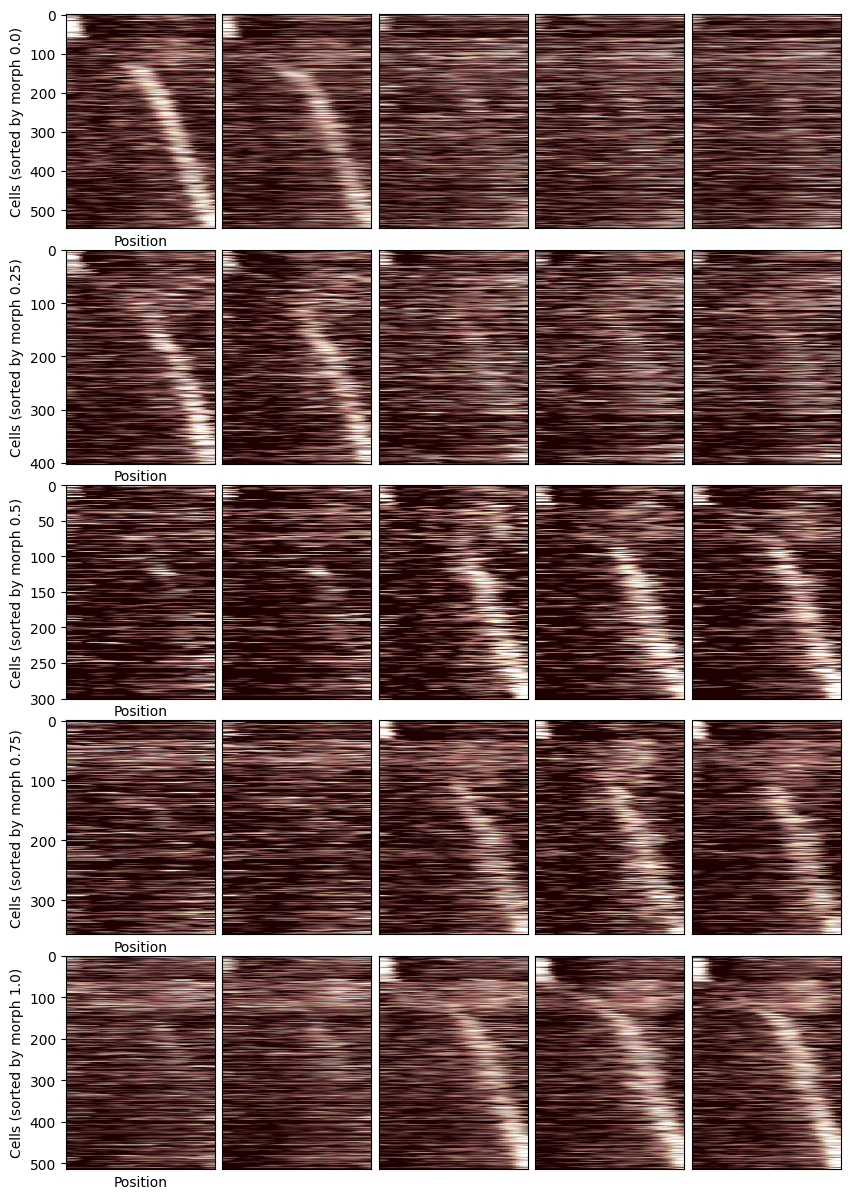

In [54]:
spks_morph_dict = m.utilities.trial_type_dict(sess.trial_matrices['spks_norm'], sess.trial_info['morphs'])
f_pc, ax_pc,PC_dict = m.place_cell_analysis.plot_placecells(spks_morph_dict, sess.place_cell_info['masks'])

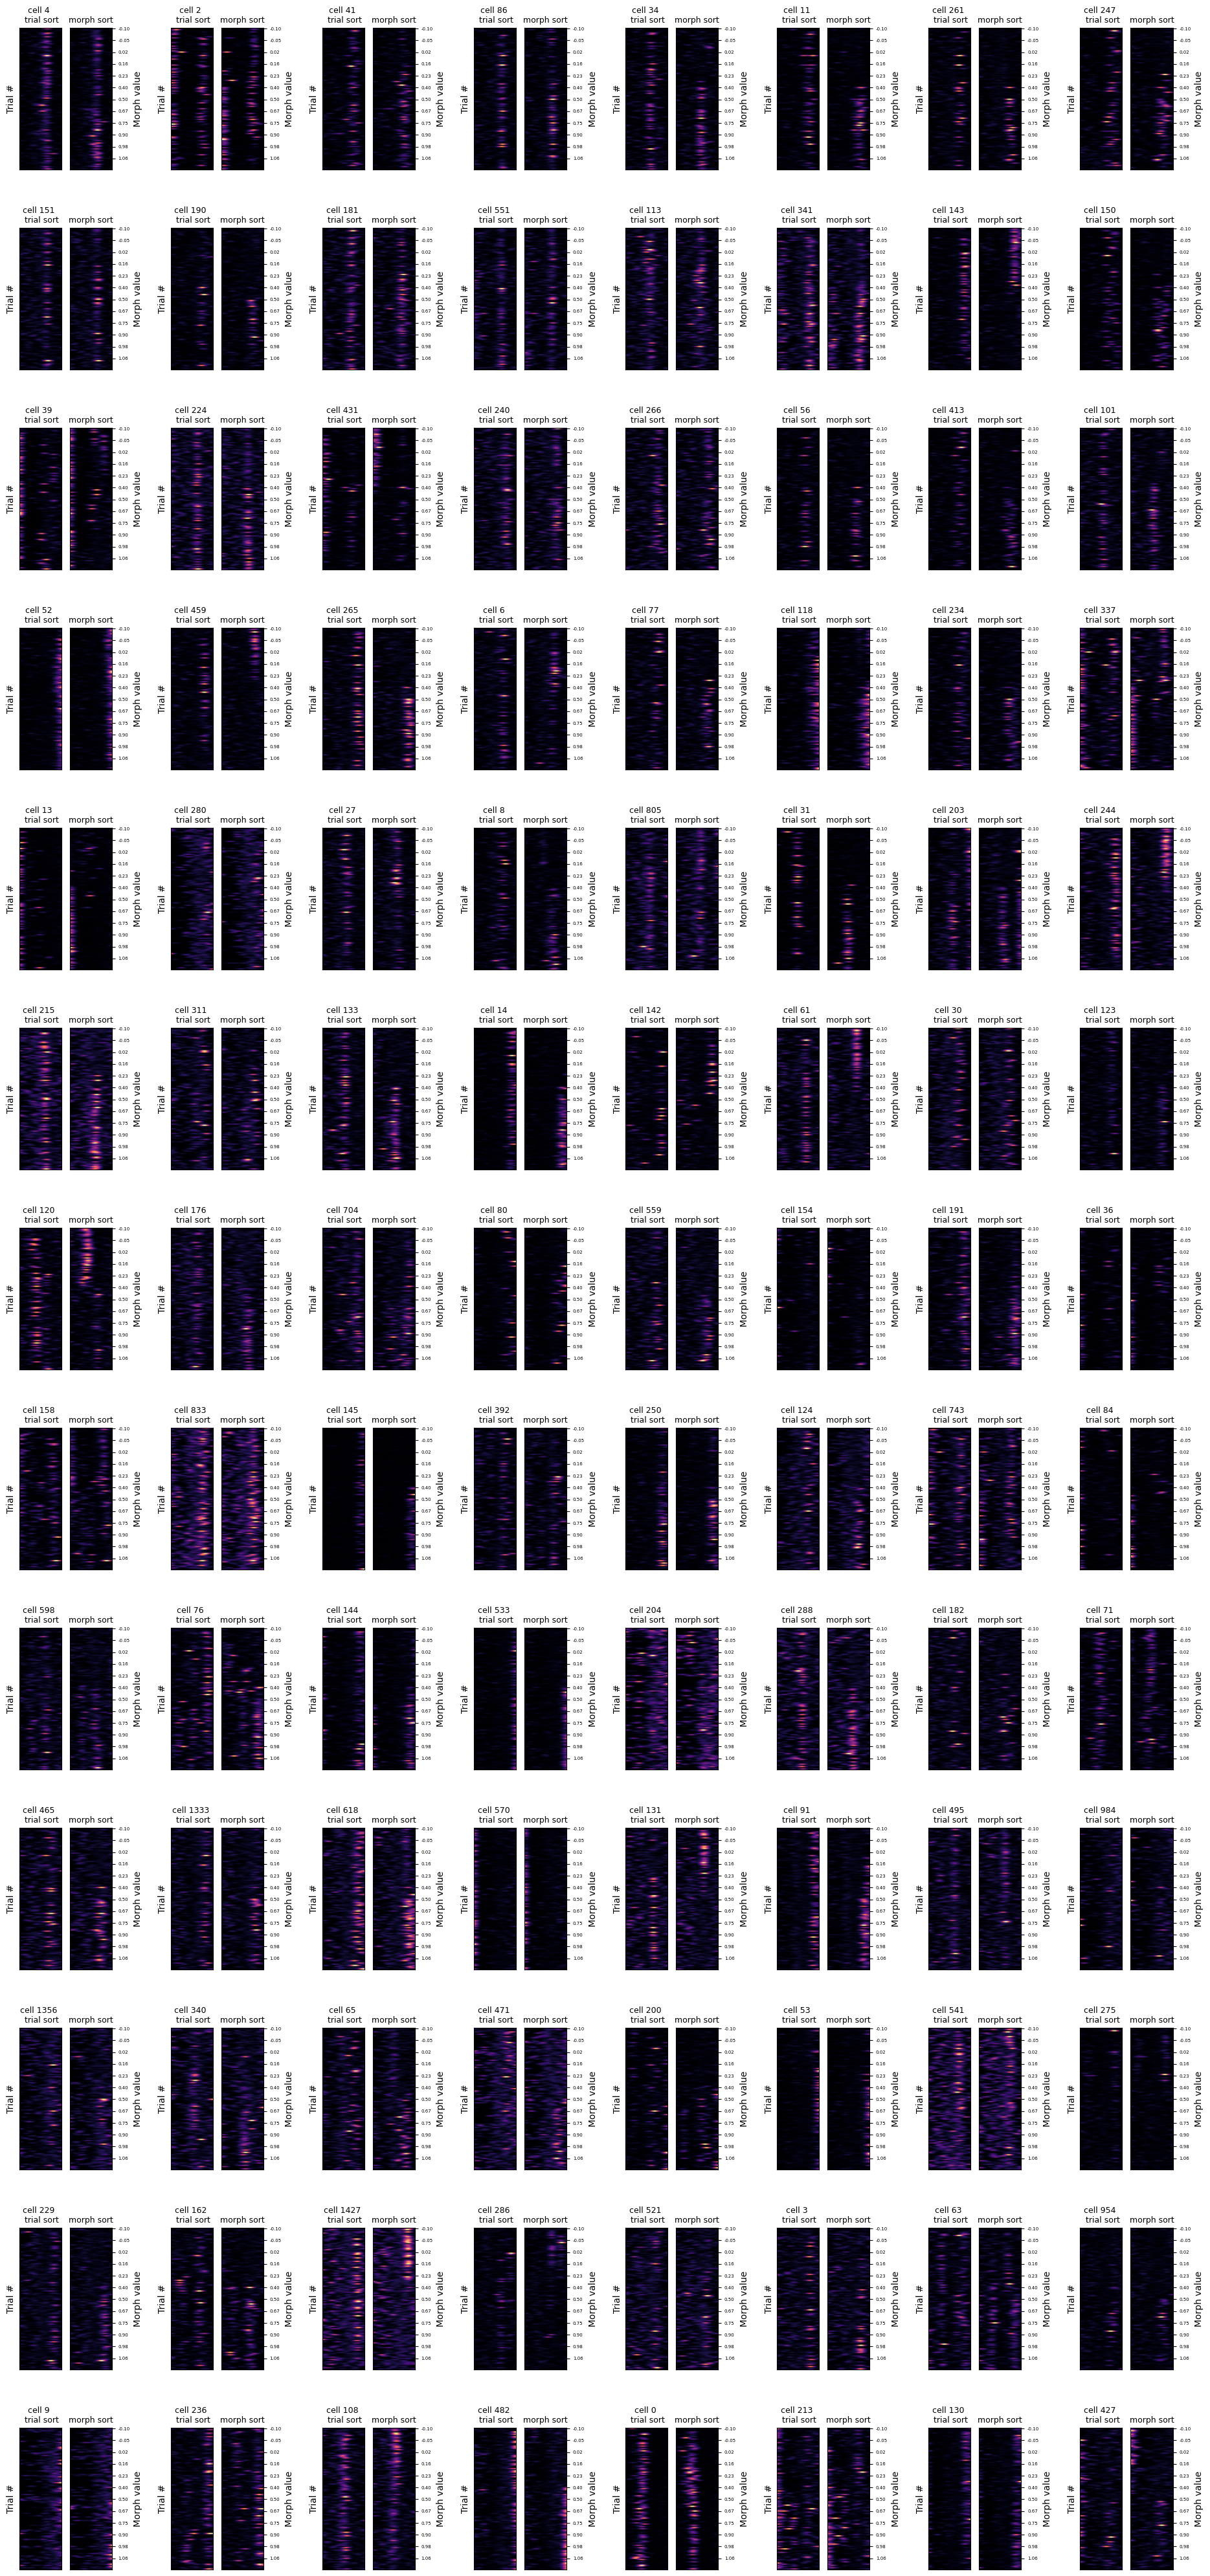

In [ ]:
# single cell plots
# plots cells with highest spatial info combined across morphs
f_singlecells = m.place_cell_analysis.plot_top_cells(
    sess.trial_matrices['spks_norm'],
    sess.place_cell_info['masks'],
    sess.place_cell_info['SI'], 
    sess.trial_info['effective_morph'],
    maxcells=104,
    ) 

0
13.578400380703648
15.211510681630305
11.869457208084476
5.919700950355286
6.483302451823785
5.979923536276077
4.598104006299632
3.8824061716880243


Text(0.5, 1.0, 'Eigenprojection of similarity matrix')

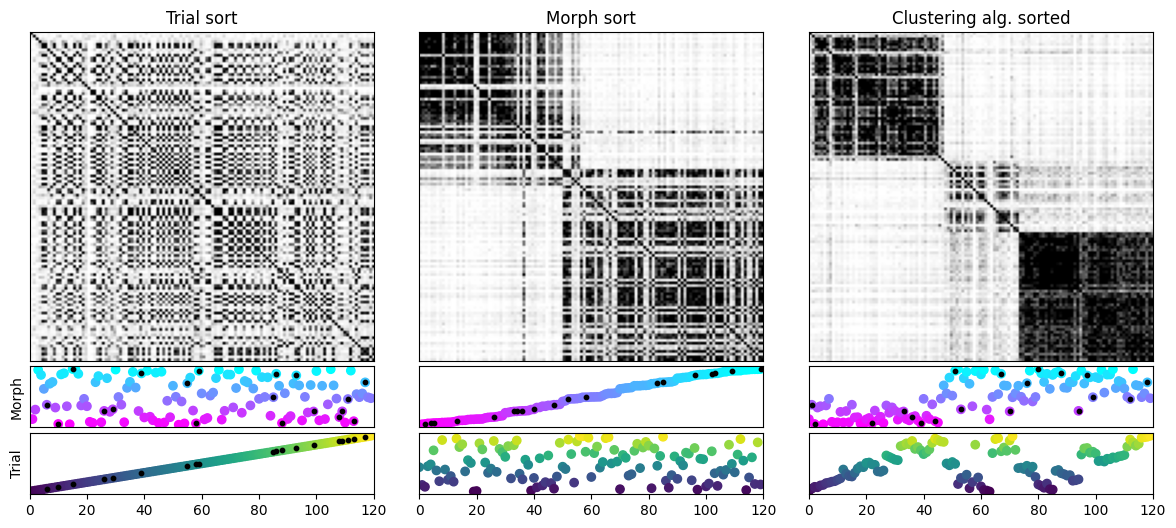

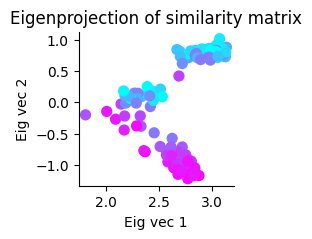

In [56]:
# trial x trial similarity matrix
spks_trial_mat = np.copy(sess.trial_matrices['spks_norm'])
spks_trial_mat[np.isnan(spks_trial_mat)]=1E-3
# S_trial_mat is trials x positions x neurons
spks_trial_mat = sp.ndimage.gaussian_filter1d(spks_trial_mat,1,axis=1) # smooth position by 1 bin

#flatten to be trial x positions*neurons
spks_tmat = np.reshape(spks_trial_mat,[spks_trial_mat.shape[0],-1])
# divide trials by l2-norm
spks_tmat = spks_tmat/np.linalg.norm(spks_tmat,ord=2,axis=-1)[:,np.newaxis]
# outer product give trial x trial cosine similarity
spks_t_rmat = np.matmul(spks_tmat,spks_tmat.T)
print((spks_t_rmat<0).sum())
f_stsm,axtup_stsm = m.similarity_matrix_analysis.plot_trial_simmat(spks_t_rmat,sess.trial_info)


# eigenvectors of similiarity matrix
fig, ax = plt.subplots(figsize=[2,2])

[w,V]=np.linalg.eig(spks_t_rmat)
order = np.argsort(w)[::-1]
w = w[order]
V=V[:,order]

# project trials onto top 3 eigenvectors
X =  np.matmul(spks_t_rmat,V[:,:3])

ax.scatter(X[:,0],X[:,1],c=1-effMorph,cmap='cool',marker='o',s=50)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Eig vec 1')
ax.set_ylabel('Eig vec 2')
ax.set_title('Eigenprojection of similarity matrix')

Text(0, 0.5, '$SF$')

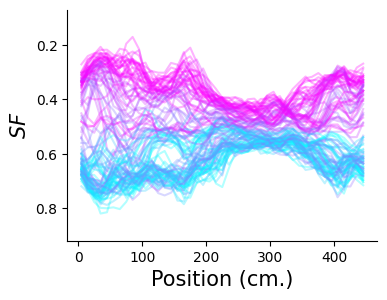

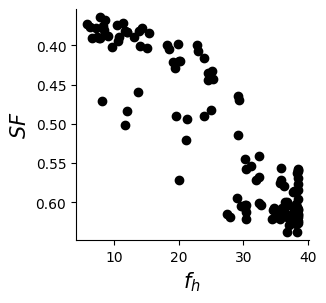

In [57]:
# similarity fraction vs position
rtsf = m.utilities.rt_similarity_fraction(spks_trial_mat,sess.trial_info,sigma=0)
f, rtsf_ax = plt.subplots(figsize=[4,3])
for t in range(rtsf.shape[0]):
    rtsf_ax.plot(np.arange(5,450,10),rtsf[t,:],alpha=.3,c=plt.cm.cool(1-sess.trial_info['effective_morph'][t]))
            
rtsf_ax.spines['top'].set_visible(False)
rtsf_ax.spines['right'].set_visible(False)
rtsf_ax.set_ylim([np.nanmax(rtsf.ravel())+.1,np.nanmin(rtsf.ravel())-.1])
rtsf_ax.set_xlabel("Position (cm.)",fontsize=15)
rtsf_ax.set_ylabel("$SF$",fontsize=15)

# summary similarity fraction
sf = m.utilities.similarity_fraction(spks_trial_mat,sess.trial_info)
f, sf_ax = plt.subplots(figsize=[3,3])
sf_ax.scatter(m.unity_transforms.xfreq(sess.trial_info['effective_morph']),sf,color='black') #,c=plt.cm.cool(1-effMorph))
sf_ax.set_ylim([np.nanmax(sf)+.01,np.nanmin(sf)-.01])
sf_ax.spines['top'].set_visible(False)
sf_ax.spines['right'].set_visible(False)
sf_ax.set_xlabel("$f_h$",fontsize=15)
sf_ax.set_ylabel("$SF$",fontsize=15)